In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [2]:
axis = pd.read_csv("data/raw/Axis_Bluechip.csv")
icici = pd.read_csv("data/raw/ICICI_Bluechip.csv")
kotak = pd.read_csv("data/raw/Kotak_Bluechip.csv")
nippon = pd.read_csv("data/raw/Nippon_Large_Cap.csv")
sbi = pd.read_csv("data/raw/SBI_Bluechip.csv")

performance = pd.read_csv("data/raw/scheme_performance.csv")

In [3]:
funds = {
    "Axis": axis,
    "ICICI": icici,
    "Kotak": kotak,
    "Nippon": nippon,
    "SBI": sbi
}

daily_returns = {}

for name, df in funds.items():

    df["date"] = pd.to_datetime(df["date"], dayfirst=True)

    df = df.sort_values("date")

    df["daily_return"] = df["nav"].pct_change()

    daily_returns[name] = df

    print(name)
    print(df.head())

Axis
           date      nav  daily_return
3578 2012-12-31  23.9920           NaN
3577 2013-01-01  23.9979      0.000246
3576 2013-01-02  24.0036      0.000238
3575 2013-01-03  24.0092      0.000233
3574 2013-01-04  24.0147      0.000229
ICICI
           date      nav  daily_return
3320 2013-01-02  15.0253           NaN
3319 2013-01-03  15.0737      0.003221
3318 2013-01-04  15.0702     -0.000232
3317 2013-01-07  15.0913      0.001400
3316 2013-01-08  15.1146      0.001544
Kotak
           date      nav  daily_return
3314 2013-01-07  30.6076           NaN
3313 2013-01-08  30.6239      0.000533
3312 2013-01-09  30.6492      0.000826
3311 2013-01-10  30.6784      0.000953
3310 2013-01-11  30.6305     -0.001561
Nippon
           date      nav  daily_return
3311 2013-01-02  14.6967           NaN
3310 2013-01-03  14.7305      0.002300
3309 2013-01-04  14.8037      0.004969
3308 2013-01-07  14.7718     -0.002155
3307 2013-01-08  14.7197     -0.003527
SBI
           date       nav  daily_ret

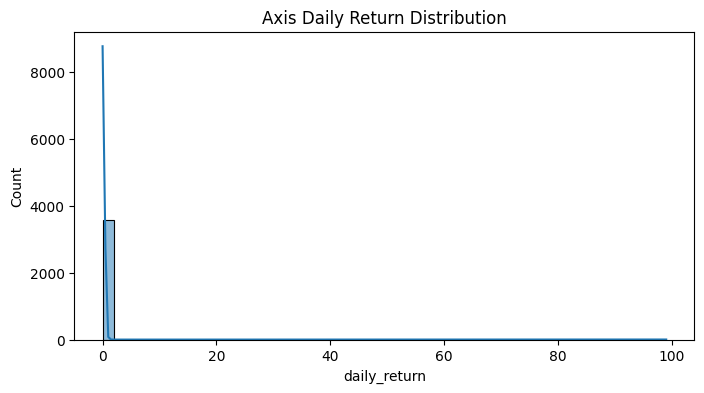

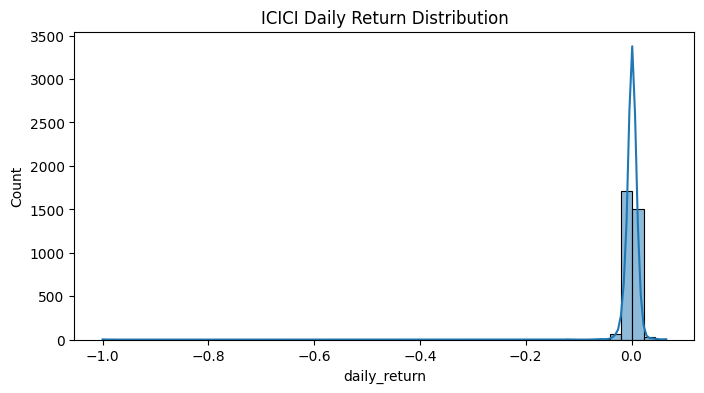

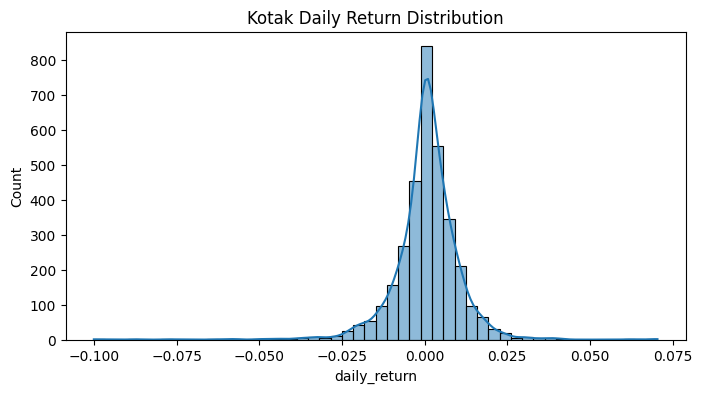

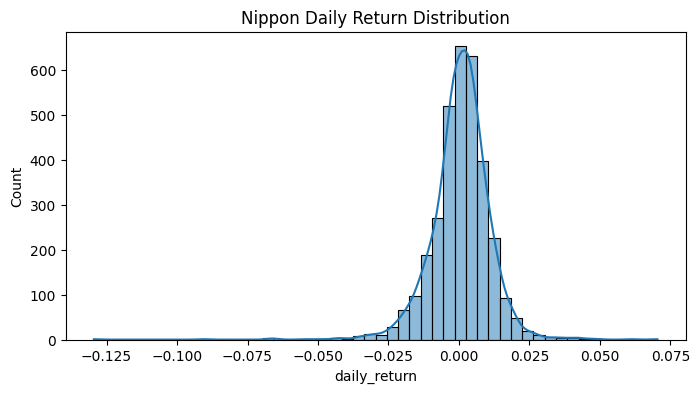

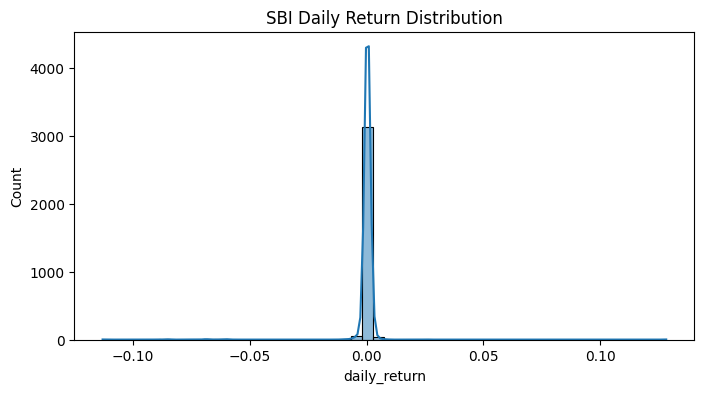

In [4]:
for name, df in daily_returns.items():

    plt.figure(figsize=(8,4))

    sns.histplot(df["daily_return"].dropna(), bins=50, kde=True)

    plt.title(f"{name} Daily Return Distribution")

    plt.show()

In [5]:
cagr = []

years = [1,3,5]

for name, df in daily_returns.items():

    nav_start = df.iloc[0]["nav"]

    nav_end = df.iloc[-1]["nav"]

    for y in years:

        value = ((nav_end/nav_start)**(1/y))-1

        cagr.append([name,y,value])

In [6]:
cagr_df = pd.DataFrame(
    cagr,
    columns=["Fund","Years","CAGR"]
)

cagr_df

,Fund,Years,CAGR
0,Axis,1,257.243644
1,Axis,3,5.368100
2,Axis,5,2.036728
3,ICICI,1,6.185454
4,ICICI,3,0.929678
5,ICICI,5,0.483511
6,Kotak,1,7.219243
7,Kotak,3,1.018106
8,Kotak,5,0.523935
9,Nippon,1,5.857485


In [9]:
import os

print(os.getcwd())

l:\mutual_fund_analysis\mutual_fund_analysis


In [10]:
cagr_df.to_csv(
    "reports/performance/cagr.csv",
    index=False
)

In [11]:
import os
print(os.getcwd())

l:\mutual_fund_analysis\mutual_fund_analysis


In [12]:
rf = 0.065

sharpe = []

for name, df in daily_returns.items():

    mean_return = df["daily_return"].mean()

    std_return = df["daily_return"].std()

    sharpe_ratio = ((mean_return - rf/252) / std_return) * np.sqrt(252)

    sharpe.append([name, sharpe_ratio])

sharpe_df = pd.DataFrame(
    sharpe,
    columns=["Fund", "Sharpe Ratio"]
)

sharpe_df = sharpe_df.sort_values(
    by="Sharpe Ratio",
    ascending=False
)

sharpe_df

,Fund,Sharpe Ratio
2,Kotak,0.695097
3,Nippon,0.572915
0,Axis,0.265457
4,SBI,-0.677508
1,ICICI,NaN


In [13]:
sharpe_df.to_csv(
    "reports/performance/sharpe_ratio.csv",
    index=False
)

In [14]:
sortino = []

for name, df in daily_returns.items():

    downside = df[df["daily_return"] < 0]["daily_return"]

    downside_std = downside.std()

    mean_return = df["daily_return"].mean()

    sortino_ratio = ((mean_return - rf/252) / downside_std) * np.sqrt(252)

    sortino.append([name, sortino_ratio])

sortino_df = pd.DataFrame(
    sortino,
    columns=["Fund", "Sortino Ratio"]
)

sortino_df

,Fund,Sortino Ratio
0,Axis,648.528278
1,ICICI,inf
2,Kotak,0.808853
3,Nippon,0.710309
4,SBI,-0.383674


In [15]:
sortino_df.to_csv(
    "reports/performance/sortino_ratio.csv",
    index=False
)

In [16]:
drawdown = []

for name, df in daily_returns.items():

    df = df.copy()

    df["running_max"] = df["nav"].cummax()

    df["drawdown"] = (df["nav"] / df["running_max"]) - 1

    max_dd = df["drawdown"].min()

    drawdown.append([name, max_dd])

drawdown_df = pd.DataFrame(
    drawdown,
    columns=["Fund", "Maximum Drawdown"]
)

drawdown_df

,Fund,Maximum Drawdown
0,Axis,-0.013924
1,ICICI,-1.000000
2,Kotak,-0.334299
3,Nippon,-0.399608
4,SBI,-0.366517


In [17]:
drawdown_df.to_csv(
    "reports/performance/max_drawdown.csv",
    index=False
)

In [18]:
nifty100 = pd.read_csv("data/raw/nifty100.csv")

nifty100["date"] = pd.to_datetime(
    nifty100["date"],
    dayfirst=True
)

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["nav"].pct_change()

nifty100.head()

,date,nav,benchmark_return
0,2022-01-01,17500,NaN
1,2022-01-02,17530,0.001714
2,2022-01-03,17490,-0.002282
3,2022-01-04,17620,0.007433
4,2022-01-05,17680,0.003405


In [19]:
from scipy.stats import linregress

alpha_beta = []

for name, df in daily_returns.items():

    temp = df.copy()

    temp = temp.merge(
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    temp = temp.dropna()

    beta, intercept, r_value, p_value, std_err = linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )

    alpha = intercept * 252

    alpha_beta.append([name, alpha, beta])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=["Fund", "Alpha", "Beta"]
)

alpha_beta_df

,Fund,Alpha,Beta
0,Axis,0.054790,-0.008794
1,ICICI,1.374261,-0.236790
2,Kotak,1.072280,0.125191
3,Nippon,1.359926,0.287106
4,SBI,0.014985,-0.047866


In [20]:
alpha_beta_df.to_csv(
    "reports/performance/alpha_beta.csv",
    index=False
)

In [21]:
scorecard = sharpe_df.copy()

# Merge Alpha
scorecard = scorecard.merge(
    alpha_beta_df[["Fund", "Alpha"]],
    on="Fund"
)

# Merge Drawdown
scorecard = scorecard.merge(
    drawdown_df,
    on="Fund"
)

In [22]:
fund_map = {
    125497: "SBI",
    120503: "ICICI",
    119551: "Axis",
    118632: "Kotak",
    121000: "Nippon"
}

In [23]:
performance["Fund"] = performance["scheme_code"].map(fund_map)

scorecard = scorecard.merge(
    performance[["Fund", "return_3y", "expense_ratio"]],
    on="Fund",
    how="left"
)

In [24]:
performance

,scheme_code,return_1y,return_3y,return_5y,expense_ratio,Fund
0,125497,12.5,18.2,20.1,1.2,SBI
1,119551,10.3,15.8,18.5,0.9,Axis
2,120503,11.7,17.0,19.3,1.1,ICICI
3,118632,13.1,19.4,21.0,1.3,Kotak
4,120841,9.5,14.0,17.5,0.7,NaN
5,119092,11.2,16.5,18.9,0.8,NaN
6,125498,12.0,18.0,20.0,1.0,NaN
7,125499,10.5,15.2,17.8,1.4,NaN
8,125500,11.8,16.9,19.0,1.2,NaN
9,125501,13.0,19.2,21.1,0.9,NaN


In [25]:
scorecard["ReturnRank"] = scorecard["return_3y"].rank(ascending=False)

scorecard["SharpeRank"] = scorecard["Sharpe Ratio"].rank(ascending=False)

scorecard["AlphaRank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["ExpenseRank"] = scorecard["expense_ratio"].rank(ascending=True)

scorecard["DrawdownRank"] = scorecard["Maximum Drawdown"].rank(ascending=False)

In [26]:
scorecard["Score"] = (
    (scorecard["ReturnRank"] * 0.30) +
    (scorecard["SharpeRank"] * 0.25) +
    (scorecard["AlphaRank"] * 0.20) +
    (scorecard["ExpenseRank"] * 0.15) +
    (scorecard["DrawdownRank"] * 0.10)
)

scorecard = scorecard.sort_values("Score")

scorecard

,Fund,Sharpe Ratio,Alpha,Maximum Drawdown,return_3y,expense_ratio,ReturnRank,SharpeRank,AlphaRank,ExpenseRank,DrawdownRank,Score
0,Kotak,0.695097,1.072280,-0.334299,19.4,1.3,1.0,1.0,3.0,4.0,2.0,1.95
2,Axis,0.265457,0.054790,-0.013924,15.8,0.9,4.0,3.0,4.0,1.0,1.0,3.00
3,SBI,-0.677508,0.014985,-0.366517,18.2,1.2,2.0,4.0,5.0,3.0,3.0,3.35
1,Nippon,0.572915,1.359926,-0.399608,NaN,NaN,NaN,2.0,2.0,NaN,4.0,NaN
4,ICICI,NaN,1.374261,-1.000000,17.0,1.1,3.0,NaN,1.0,2.0,5.0,NaN


In [27]:
scorecard["Score"] = (
    (scorecard["ReturnRank"] * 0.30) +
    (scorecard["SharpeRank"] * 0.25) +
    (scorecard["AlphaRank"] * 0.20) +
    (scorecard["ExpenseRank"] * 0.15) +
    (scorecard["DrawdownRank"] * 0.10)
)

scorecard = scorecard.sort_values("Score")

scorecard

,Fund,Sharpe Ratio,Alpha,Maximum Drawdown,return_3y,expense_ratio,ReturnRank,SharpeRank,AlphaRank,ExpenseRank,DrawdownRank,Score
0,Kotak,0.695097,1.072280,-0.334299,19.4,1.3,1.0,1.0,3.0,4.0,2.0,1.95
2,Axis,0.265457,0.054790,-0.013924,15.8,0.9,4.0,3.0,4.0,1.0,1.0,3.00
3,SBI,-0.677508,0.014985,-0.366517,18.2,1.2,2.0,4.0,5.0,3.0,3.0,3.35
1,Nippon,0.572915,1.359926,-0.399608,NaN,NaN,NaN,2.0,2.0,NaN,4.0,NaN
4,ICICI,NaN,1.374261,-1.000000,17.0,1.1,3.0,NaN,1.0,2.0,5.0,NaN


In [28]:
scorecard.to_csv(
    "reports/performance/fund_scorecard.csv",
    index=False
)

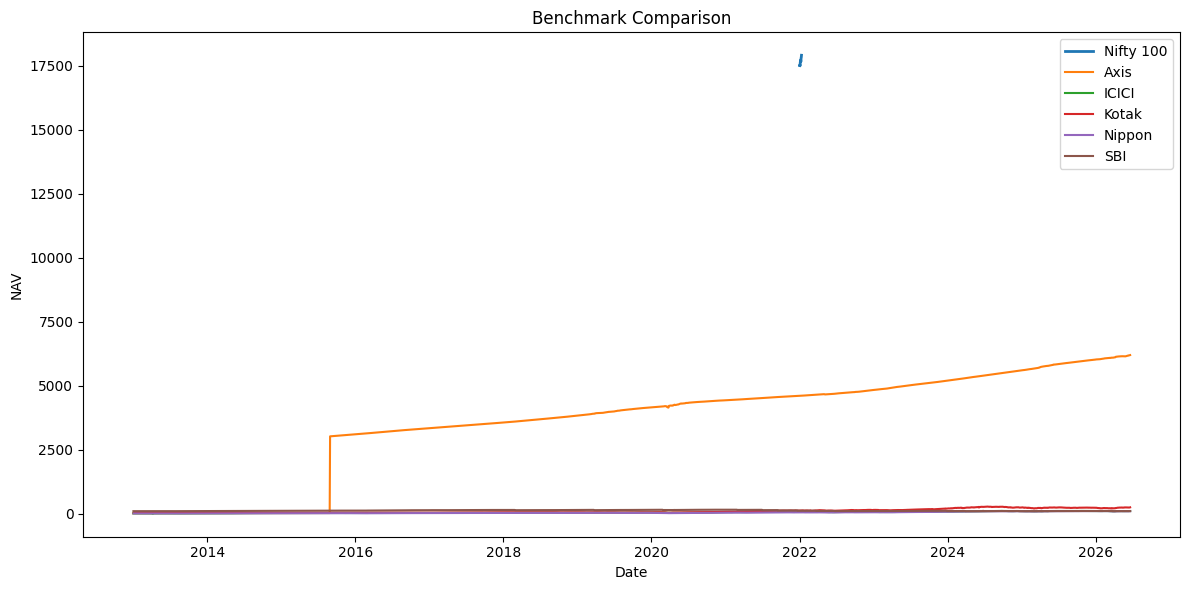

In [29]:
plt.figure(figsize=(12,6))

plt.plot(
    nifty100["date"],
    nifty100["nav"],
    label="Nifty 100",
    linewidth=2
)

for fund, df in daily_returns.items():

    plt.plot(
        df["date"],
        df["nav"],
        label=fund
    )

plt.title("Benchmark Comparison")

plt.xlabel("Date")

plt.ylabel("NAV")

plt.legend()

plt.tight_layout()

plt.savefig("reports/performance/benchmark_comparison.png")

plt.show()

In [ ]:
tracking = []

for fund, df in daily_returns.items():

    temp = df.merge(
        nifty100[["date", "benchmark_return"]],
        on="date"
    )

    temp = temp.dropna()

    error = (
        temp["daily_return"] 
        temp["benchmark_return"]
    ).std() * np.sqrt(252)

    tracking.append([fund, error])

tracking_df = pd.DataFrame(
    tracking,
    columns=["Fund", "Tracking Error"]
)

tracking_df

,Fund,Tracking Error
0,Axis,0.066089
1,ICICI,0.138725
2,Kotak,0.112764
3,Nippon,0.127910
4,SBI,0.068677


In [31]:
tracking_df.to_csv(
    "reports/performance/tracking_error.csv",
    index=False
)

In [32]:
performance

,scheme_code,return_1y,return_3y,return_5y,expense_ratio,Fund
0,125497,12.5,18.2,20.1,1.2,SBI
1,119551,10.3,15.8,18.5,0.9,Axis
2,120503,11.7,17.0,19.3,1.1,ICICI
3,118632,13.1,19.4,21.0,1.3,Kotak
4,120841,9.5,14.0,17.5,0.7,NaN
5,119092,11.2,16.5,18.9,0.8,NaN
6,125498,12.0,18.0,20.0,1.0,NaN
7,125499,10.5,15.2,17.8,1.4,NaN
8,125500,11.8,16.9,19.0,1.2,NaN
9,125501,13.0,19.2,21.1,0.9,NaN
